In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator


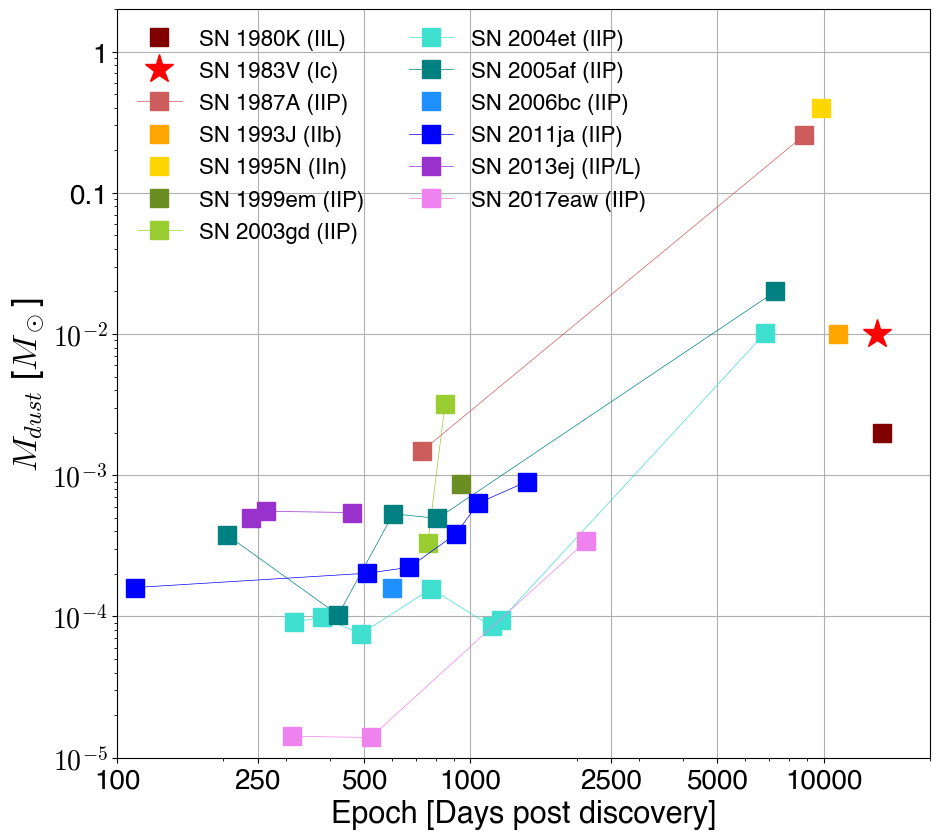

In [18]:
# Load digitized data
df = pd.read_csv("/Users/sophiakressy/Desktop/digitized_supernova_dust_refined.csv")

ssize = 13
stsize = 21
style = {
    "SN 1980K (IIL)": {"color":"maroon", "marker":"s", "size":ssize, "linestyle":'none'},
    "SN 1983V (Ic)": {"color":"red", "marker":"*", "size":stsize, "linestyle":'none'},
    "SN 1987A (IIP)": {"color":"indianred", "marker":"s", "size":ssize, "linestyle":'-'},
    "SN 1993J (IIb)": {"color":"orange", "marker":"s", "size":ssize, "linestyle":'none'},
    "SN 1995N (IIn)": {"color":"gold", "marker":"s", "size":ssize, "linestyle":'none'},
    "SN 1999em (IIP)": {"color":"olivedrab", "marker":"s", "size":ssize, "linestyle":'none'},
    "SN 2003gd (IIP)": {"color":"yellowgreen", "marker":"s", "size":ssize, "linestyle":'-'},
    "SN 2004et (IIP)": {"color":"turquoise", "marker":"s", "size":ssize, "linestyle":'-'},
    "SN 2005af (IIP)": {"color":"teal", "marker":"s", "size":ssize, "linestyle":'-'},
    "SN 2006bc (IIP)": {"color":"dodgerblue", "marker":"s", "size":ssize, "linestyle":'none'},
    "SN 2011ja (IIP)": {"color":"blue", "marker":"s", "size":ssize, "linestyle":'-'},
    "SN 2013ej (IIP/L)": {"color":"darkorchid", "marker":"s", "size":ssize, "linestyle":'-'},
    "SN 2017eaw (IIP)": {"color":"violet", "marker":"s", "size":ssize, "linestyle":'-'},
    
    
}

plt.rcParams.update({
    "font.family": "Helvetica",
    "mathtext.fontset": "cm",   # keep LaTeX math look
})

fig, ax = plt.subplots(figsize=(9.5,8.5))

days = []
dmass = []
# plot each series
for name, g in df.groupby("series"):
    s = style[name]
    g = g.sort_values("x_epoch_days")
    days.append(g["x_epoch_days"])
    dmass.append(g["Mdust_Msun"])
    ax.plot(g["x_epoch_days"], g["Mdust_Msun"],
            color=s["color"], marker=s["marker"], linestyle="-",
            linewidth=0.5, markersize=s["size"], label=name)

# linear regression: y = 7e-6x - 0.0018, R2 = 0.219
# exponential regression: y = 0.0002ep(0.0004x), R2 = 0.0044

# regression in log space (exponential)
# x = np.linspace(1e2, 20000, 100)
# y =  0.0002*np.exp(0.0004*x)
# ax.plot(x, y, "--", color="k", linewidth=2, alpha=0.7, label="Linear Regression")

# logx = np.log10(df["x_epoch_days"].values)
# logy = np.log10(df["Mdust_Msun"].values)
# slope, intercept = np.polyfit(logx, logy, 1)
# xfit = np.logspace(2, 4, 300)
# yfit = 10 ** (intercept + slope*np.log10(xfit))
# sigma = np.std(logy - (intercept + slope*logx))
# ax.plot(xfit, yfit, "--", color="k", linewidth=2, label="Linear Regression")
# ax.fill_between(xfit, 10**(np.log10(yfit)-sigma), 10**(np.log10(yfit)+sigma),
#                 color="gray", alpha=0.4, label=r"1-$\sigma$ uncertainty")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e2, 20000)
ax.set_ylim(1e-5, 2)

# Set custom x and y ticks and labels
ax.set_xticks([100, 250, 500, 1000, 2500, 5000, 10000])
ax.set_xticklabels(["100", "250", "500", "1000", "2500", "5000", "10000"], fontsize=20)
ax.set_yticks([1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1])
ax.set_yticklabels([r"$10^{-5}$", r"$10^{-4}$", r"$10^{-3}$", r"$10^{-2}$", r"0.1", r"1"], fontsize=20)

ax.set_xlabel("Epoch [Days post discovery]", fontsize=22)
ax.set_ylabel(r"$M_{dust}$ [$M_\odot$]", fontsize=25)

# tidy legend
handles = [Line2D([0],[0], color=style[k]["color"], marker=style[k]["marker"],
                  linestyle=style[k]["linestyle"], linewidth=0.5, markersize=style[k]["size"], label=k)
           for k in style]
# handles += [Line2D([0],[0], color="k", linestyle="--", linewidth=2, alpha=0.7, label="Linear Regression"),
#             Patch(facecolor="gray", alpha=0.2, label=r"1-$\sigma$ uncertainty")]

ax.legend(handles=handles, loc="upper left", frameon=False, fontsize=16, ncol=2)

plt.tight_layout()
plt.grid()
plt.savefig('/Users/sophiakressy/Desktop/days_mass_reproduction.pdf')